<a href="https://colab.research.google.com/github/changyunyeong/MachineLearning_2026_01/blob/main/ML%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8_3%E1%84%8C%E1%85%AE%E1%84%8E%E1%85%A1_Classification(1)_%E1%84%83%E1%85%A1%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 머신러닝 실습 3주차

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    log_loss
)

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

---

# **Part 1. Logistic Regression**

Classification 문제에서 예측값은 단순한 실수가 아니라 0~1 사이의 확률값이어여 함.

### ■ **Logistic Regression**
* **Link function**
  * 선형 예측값과 확률을 연결하는 함수
  * logistic regression은 logit을 선형 모델로 두고, sigmoid 함수를 통해 확률로 변환
  
$$
\boxed{\text{logit}(p)=\log\frac{p}{1-p}}
$$

$$
\boxed{P(Y=1\mid X=x)=\frac{\exp(\beta^T x)}{1+\exp(\beta^T x)}}
$$

  ---
### ■ **Logistic Regression Training**

* **Maximum Likelihood Estimator**
  * 각 관측치의 클래스가 나올 likelihood를 가장 크게 만드는 계수 $β$를 찾음
  * 각 데이터의 response variable는 Bernoulli 분포를 따른다고 가정
  * $\mathrm{Loss} = - \log \mathrm{Likelihood}$

$$
\boxed{\mathrm{Likelihood}(\beta)
= \prod_{i=1}^{N} (\pi(x_i))^{y_i} (1 - \pi(x_i))^{1 - y_i}}
$$

$$
\boxed{\log \mathrm{Likelihood}(\beta)
= \sum_{i=1}^{N} \left[ y_i \log \pi(x_i) + (1 - y_i) \log (1 - \pi(x_i)) \right]}
$$

* **Training Methods**

  **1. Gradient Descent**
    * 현재 계수에서 손실함수의 기울기를 계산
    * 종류: Batch GD, SGD, Mini-batch GD

  **2. Newton-Raphson**
    * Hessian 정보까지 사용
    * 더 빠르게 수렴할 수 있으나, 계산 비용이 큼

  ---

### ■ **Statistical Test for Coefficients**
* 각 계수가 정말 의미 있는지 확인
* p-value가 작으면 해당 변수가 분류에 통계적으로 중요함
* **Wald test**
  * $H_0:\beta_j=0$
  * 계수 부호가 +이면, 해당 변수 증가가 클래스 1의 확률 증가 방향과 연관됨  

  ---

### ■ **Multiple Logistic Regression**
* 클래스가 3개 이상인 경우, baseline-category logit model을 사용해야함
  1. 하나의 기준 클래스(baseline)를 정함
  2. 나머지 클래스 각각에 대해 log-odds를 모델링
  3. 가장 큰 확률을 갖는 클래스로 분류

---

## **Exercise 1**

**[Dataset]**
* [Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)
* $X$: 유방 조직의 세포핵(cell nuclei) 특성
* $y$: 악성 여부 (0: benign, 1: malignant)

In [ ]:
# load dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("X shape:", X.shape)
print("y shape:", y.shape)
print()

X.head()

X shape: (569, 30)
y shape: (569,)



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


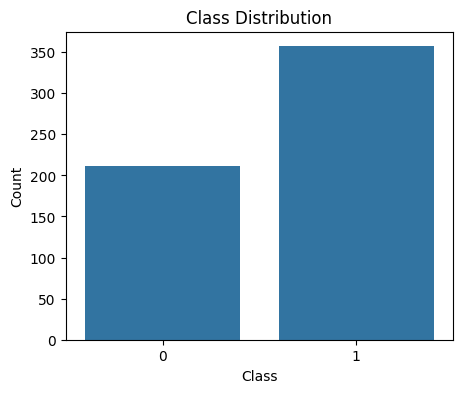

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


In [ ]:
# 클래스 분포
plt.figure(figsize=(5, 4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(y.value_counts(normalize=True))

In [ ]:
print(X.columns.to_list())

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


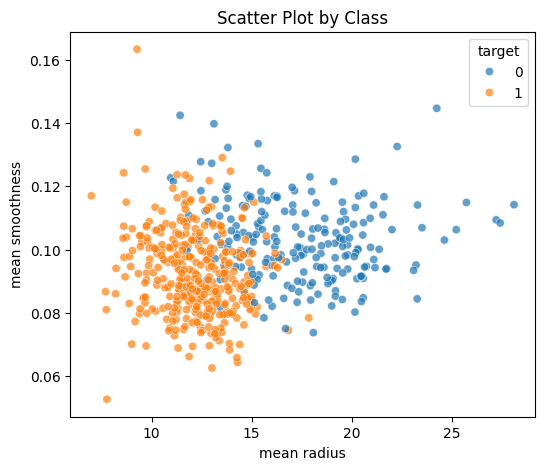

In [ ]:
# 두 변수를 골라 sactter plot 확인

a1 = 'mean radius'
a2 = 'mean smoothness'

plot_df = X[[a1, a2]].copy()
plot_df['target'] = y

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=plot_df,
    x=a1,
    y=a2,
    hue='target',
    alpha=0.7
)
plt.title("Scatter Plot by Class")
plt.show()

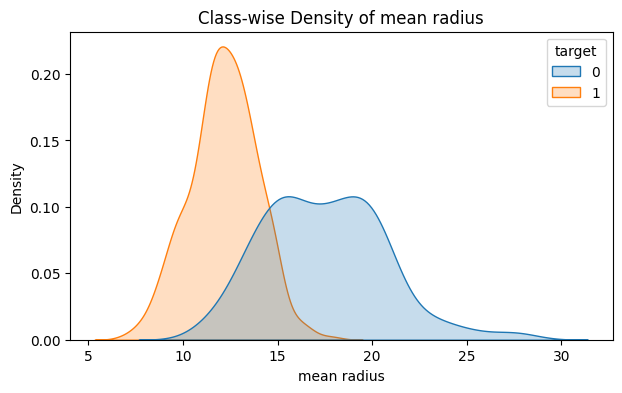

In [ ]:
feature_name = a1
vis_nb_df = X[[feature_name]].copy()
vis_nb_df['target'] = y

plt.figure(figsize=(7, 4))
sns.kdeplot(data=vis_nb_df, x=feature_name, hue='target', fill=True, common_norm=False)
plt.title(f"Class-wise Density of {feature_name}")
plt.show()

**[Logit Function]**
$$
\boxed{\text{logit}(p)=\log\frac{p}{1-p}}
$$

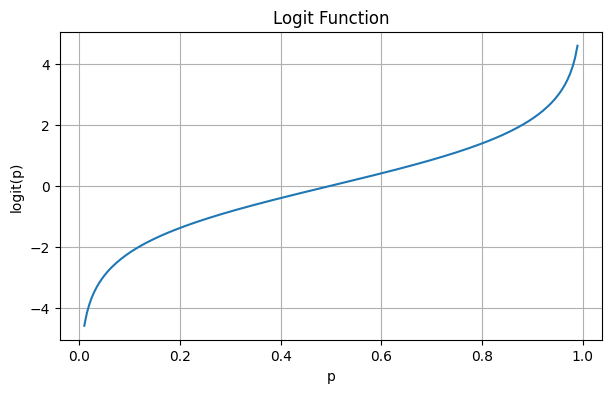

In [ ]:
p_vals = np.linspace(0.01, 0.99, 200)
logit_vals = np.log(p_vals / (1 - p_vals))

plt.figure(figsize=(7, 4))
plt.plot(p_vals, logit_vals)
plt.xlabel("p")
plt.ylabel("logit(p)")
plt.title("Logit Function")
plt.grid(True)
plt.show()

**[Sigmoid Function]**
$$
P(Y=1\mid X=x)=\frac{\exp(\beta^T x)}{1+\exp(\beta^T x)}=\boxed{\frac{1}{1+\exp(-\beta^T x)}}
$$

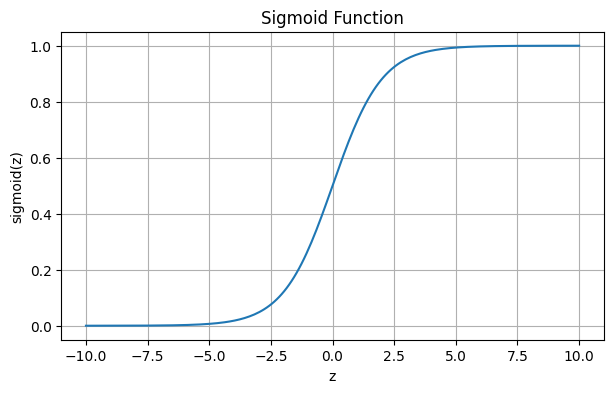

In [ ]:
def sigmoid(z):
    # sigmoid
    y = 1 / (1 + np.exp(-z))
    return y

z = np.linspace(-10, 10, 200)
p = sigmoid(z)

plt.figure(figsize=(7, 4))
plt.plot(z, p)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

**[Evaluation Metric]**

Classification 문제에서는 일반적으로 아래와 같은 지표를 확인
* **Accuracy:** 전체 샘플 중에서 정확하게 예측한 비율
* **Precision:** 모델이 positive라고 예측한 것 중 실제로 맞은 비율
* **Recall:** 실제 positive라고 중에서 모델이 얼마나 잘 찾아냈는지
* **F1-score:** Precision과 Recall의 조화 평균

In [ ]:
def evaluate_classifier(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    print(f"[{model_name}]")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall   :", round(recall_score(y_test, y_pred), 4))
    print("F1-score :", round(f1_score(y_test, y_pred), 4))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

**[Logistic Regression Training]**

In [ ]:
# train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [ ]:
logit_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

logit_model.fit(X_train, y_train)
print(f"n_iter_: {logit_model.named_steps["model"].n_iter_}")

print()

evaluate_classifier(logit_model, X_test, y_test, "Logistic Regression")

n_iter_: [19]

[Logistic Regression]
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861

Confusion Matrix
[[41  1]
 [ 1 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**[SGD Classifier]**

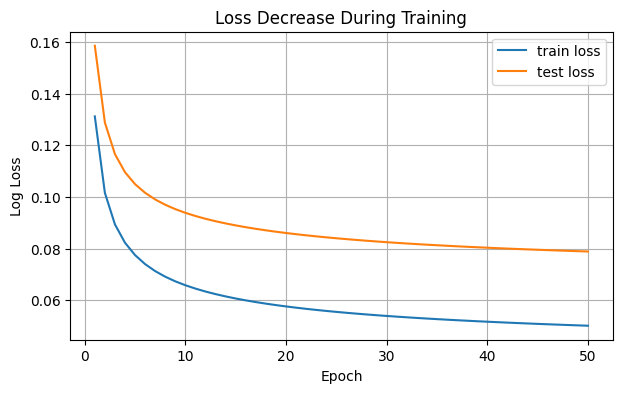

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd_logit = SGDClassifier(loss="log_loss", max_iter=1, learning_rate="constant",
                          eta0=0.01, random_state=42, tol=None)

classes = np.unique(y_train)
train_losses = []
test_losses = []

for epoch in range(1, 51):
    sgd_logit.partial_fit(X_train_scaled, y_train, classes=classes)

    train_proba = sgd_logit.predict_proba(X_train_scaled)
    test_proba = sgd_logit.predict_proba(X_test_scaled)

    train_losses.append(log_loss(y_train, train_proba))
    test_losses.append(log_loss(y_test, test_proba))

plt.figure(figsize=(7, 4))
plt.plot(range(1, 51), train_losses, label='train loss')
plt.plot(range(1, 51), test_losses, label='test loss')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Loss Decrease During Training")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 각 샘플이 클래스 1일 확률
logit_proba = logit_model.predict_proba(X_test)[:, 1]

proba_df = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "predicted_probability": logit_proba
})

proba_df.head(10)

,actual,predicted_probability
0,0,5.888242e-08
1,1,9.999887e-01
2,0,6.410825e-03
3,1,5.335085e-01
4,0,6.525001e-10
5,1,9.921604e-01
6,1,9.999828e-01
7,0,5.635275e-07
8,0,5.431637e-05
9,0,8.041849e-11


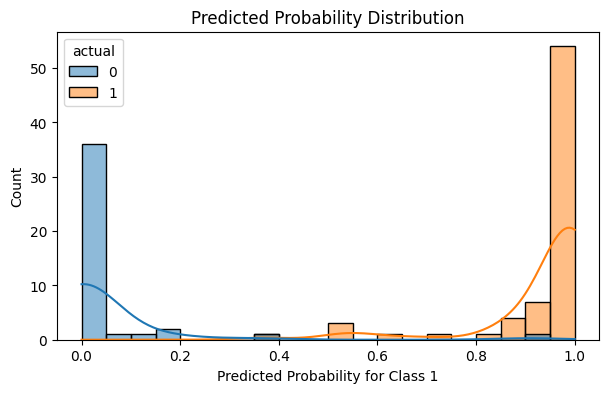

In [ ]:
proba_vis_df = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "pred_prob": logit_proba
})
plt.figure(figsize=(7, 4))
sns.histplot(data=proba_vis_df, x="pred_prob", hue="actual", bins=20, kde=True)
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability for Class 1")
plt.show()

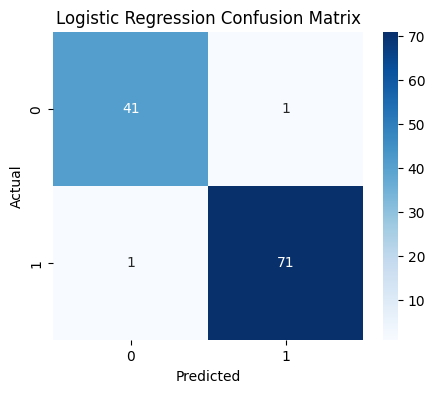

In [ ]:
y_pred_logit = logit_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_logit)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**[Coefficients]**

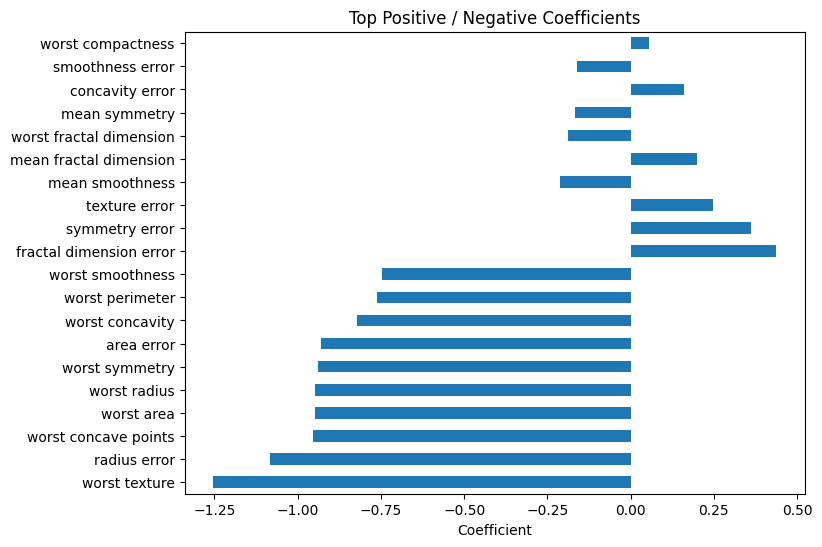

In [ ]:
coef = pd.Series(
    logit_model.named_steps["model"].coef_[0],
    index=X.columns
).sort_values(key=np.abs, ascending=False)

top_coef = pd.concat([coef.head(10), coef.tail(10)])

plt.figure(figsize=(8, 6))
top_coef.plot(kind='barh')
plt.title("Top Positive / Negative Coefficients")
plt.xlabel("Coefficient")
plt.show()

-------

# **Part 2. Bayes Classifier**

Bayes classifier는 확률론적 관점에서 분류를 수행하는 방법임. 입력 $X$가 주어졌을 때 각 클래스 $Y$의 사후확률 posterior 를 계산하고, 그 값이 가장 큰 클래스를 선택함.

### ■ **Bayes Theorem**

* 주어진 특성 X에서 클래스 Y일 확률 $P(Y \mid X)$를 구한다.
$$
\boxed{P(Y \mid X) = \frac{P(X \mid Y)P(Y)}{P(X)}}
$$
  * **Prior ($P(Y)$):** 클래스 자체의 사전확률
  * **Likelihood ($P(X \mid Y)$):** 클래스가 주어졌을 때 이런 특징이 나타날 확률
  * **Posterior ($P(Y \mid X)$):** 실제로 우리가 분류에 쓰는 값
  * **Evidence ($P(X)$):** 정규화 상수

* **Maximum A Posterior (MAP)**
  * 실제 분류에서는 $P(X)$가 클래스마다 공통이므로, $\arg\max_Y P(Y\mid X)$는 $\arg\max_Y P(X\mid Y)P(Y)$와 같음
  * 주어진 속성 $(X_1, X_2, \dots, X_d)$에 대해 $P(Y \mid X_1, X_2, \dots, X_d)$를 최대화하는 Y를 선택


  ---

### ■ **Naïve Bayes Classifier**
* **[핵심 가정] Conditional Independence**
  $$
  \boxed{P(X_1,\dots,X_d\mid Y)=\prod_{i=1}^d P(X_i\mid Y)}
  $$
  * 클래스 $Y$가 주어졌을 때, 속성들 $X_1,\dots,X_d$는 서로 독립
  * $P(X_1, X_2, \dots, X_d \mid Y)$를 직접 추정할 필요 없이, 변수별 조건부확률의 곱으로 분해할 수 있어 계산이 매우 단순해짐.

* **Training**
  * 각 클래스의 prior $P(Y)$ 추정
  * 각 속성에 대해 $P(X_i\mid Y)$ 추정
* **Test**
  * 새 데이터 $x=(x_1,\dots,x_d)$에 대해 $P(Y=c)\prod_i P(X_i=x_i\mid Y=c)$를 계산
  * 가장 큰 값을 주는 클래스를 선택
* **Estimate Probabilities**
  * **Categorical attributes:** 빈도 기반으로 계산
  $$\boxed{P(X_j=a \mid Y=c)=\frac{\#(X_j=a, Y=c)}{\#(Y=c)}}$$
  * **Continuous attributes:**
    1. **Discretization:** 구간(bin)으로 나누어 categorical처럼 처리
    2. **Probability density estimation:** 특정 분포를 가정하고 클래스별 평균, 분산을 추정

  ---

### ■ **Bayesian Belief Network**

Bayesian Belief Network(BBN)는 속성 간 의존성을 반영하지 못하는 Naïve Bayes의 한계를 보완함

* **Naïve Bayes의 단점**
  * Conditional Independence 가정이 너무 강함
  * 어떤 $P(X_i \mid Y)$가 0이면 전체 곱이 0이 됨
  * Attribute 간 상관이 큰 경우 특히 성능 저하

* **Probabilistic Graphical Model**
  * DAG(Directed Acyclic Graph) 로 변수들 사이의 의존관계를 표현
  * 각 node는 변수, edge는 의존관계
    * 각 node에는 CPT(Conditional Probability Table) 가 연결됨
    * 한 node는 부모(parent) 가 주어지면, 비자손(nondescendants)과 조건부 독립
  * **d-separation (Directed Separation)**
    * 관측된 node가 무엇인지에 따라 두 변수의 독립/종속 관계가 달라짐
    1. **Chain**: A → C → B
    2. **Fork**: A ← C → B
    3. **V-structure**: A → C ← B
  
* Naïve Bayes는 클래스 $Y$가 모든 속성의 부모인 아주 단순한 구조의 BBN임.

---



## **Exercise 2**

**[Compute Posterior]**
* P(Y=1) = 0.4
* P(Y=0) = 0.6
* P(X|Y=1) = 0.7
* P(X|Y=0) = 0.2
* P(X) = ?

In [ ]:
p_y1 = 0.4
p_y0 = 0.6
p_x_given_y1 = 0.7
p_x_given_y0 = 0.2

p_x = p_x_given_y1 * p_y1 + p_x_given_y0 * p_y0

p_y1_given_x = (p_x_given_y1 * p_y1) / p_x
p_y0_given_x = (p_x_given_y0 * p_y0) / p_x

print("P(X) =", round(p_x, 4))
print("P(Y=1 | X) =", round(p_y1_given_x, 4))
print("P(Y=0 | X) =", round(p_y0_given_x, 4))

P(X) = 0.4
P(Y=1 | X) = 0.7
P(Y=0 | X) = 0.3


**[Gaussian Naive Bayes]**

In [ ]:
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

evaluate_classifier(gnb_model, X_test, y_test, "Gaussian Naive Bayes")

[Gaussian Naive Bayes]
Accuracy : 0.9386
Precision: 0.9452
Recall   : 0.9583
F1-score : 0.9517

Confusion Matrix
[[38  4]
 [ 3 69]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



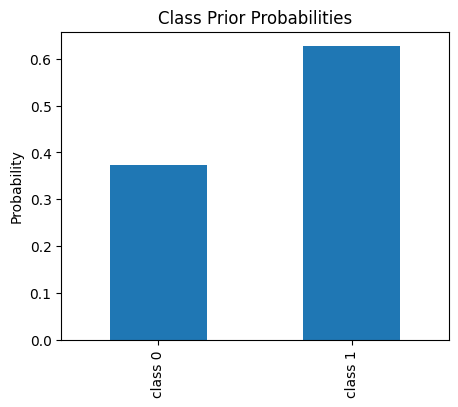

,0
class 0,0.373626
class 1,0.626374


In [ ]:
prior_series = pd.Series(gnb_model.class_prior_, index=["class 0", "class 1"])

plt.figure(figsize=(5, 4))
prior_series.plot(kind='bar')
plt.title("Class Prior Probabilities")
plt.ylabel("Probability")
plt.show()

prior_series

In [ ]:
# posterior probability
gnb_proba = gnb_model.predict_proba(X_test)

pd.DataFrame(
    gnb_proba[:10],
    columns=["P(class=0)", "P(class=1)"]
)

,P(class=0),P(class=1)
0,1.000000e+00,2.641700e-92
1,9.685177e-18,1.000000e+00
2,9.999948e-01,5.195387e-06
3,3.397346e-01,6.602654e-01
4,1.000000e+00,1.394117e-139
5,1.536709e-12,1.000000e+00
6,5.795119e-13,1.000000e+00
7,1.000000e+00,1.289240e-52
8,1.000000e+00,1.405073e-32
9,1.000000e+00,1.064514e-110


In [ ]:
# prior probability

print("Class prior probabilities:")
print(gnb_model.class_prior_)

Class prior probabilities:
[0.37362637 0.62637363]


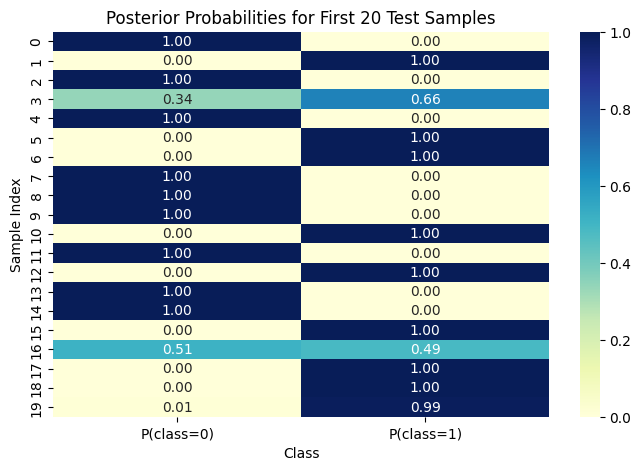

In [ ]:
gnb_proba_vis = gnb_model.predict_proba(X_test[:20])

posterior_df = pd.DataFrame(
    gnb_proba_vis,
    columns=["P(class=0)", "P(class=1)"]
)

plt.figure(figsize=(8, 5))
sns.heatmap(posterior_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Posterior Probabilities for First 20 Test Samples")
plt.xlabel("Class")
plt.ylabel("Sample Index")
plt.show()

In [ ]:
nb_result_df = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "predicted": gnb_model.predict(X_test),
    "P(class=0)": gnb_model.predict_proba(X_test)[:, 0],
    "P(class=1)": gnb_model.predict_proba(X_test)[:, 1]
})

nb_result_df.head(10)

,actual,predicted,P(class=0),P(class=1)
0,0,0,1.000000e+00,2.641700e-92
1,1,1,9.685177e-18,1.000000e+00
2,0,0,9.999948e-01,5.195387e-06
3,1,1,3.397346e-01,6.602654e-01
4,0,0,1.000000e+00,1.394117e-139
5,1,1,1.536709e-12,1.000000e+00
6,1,1,5.795119e-13,1.000000e+00
7,0,0,1.000000e+00,1.289240e-52
8,0,0,1.000000e+00,1.405073e-32
9,0,0,1.000000e+00,1.064514e-110


-------

# **Part 3. K-NearestNeighbors**

KNN은 "가까운 데이터는 비슷한 클래스를 가진다"라는 아이디어에 따라 거리 기반으로 분류를 수행하는 방법임.

### ■ **Nearest Neighbor Classifiers**

* **Basic idea**
  * 별도의 복잡한 모형을 학습하는 대신 주변 이웃의 정보만 보고 판단
  * **[Training]**
    * 레이블이 있는 훈련 데이터 준비
    * (A) 거리 척도 결정
    * (B) $k$ 값 결정
    * (C) 이웃의 레이블을 어떻게 종합할지 결정
  * **[Test]**
    0. 새 데이터가 들어오면
    1. 훈련 데이터와의 거리 계산
    2. 가장 가까운 $k$개 선택
    3. 다수결 또는 가중평균으로 라벨을 종합해 최종 클래스 결정
  

* **A. Distance Measure**
  1. **Euclidean distance:** $\sqrt{\sum_{i=1}^{p} (x_i - y_i)^2}$
  2. **Manhattan distance:** $\sum_{i=1}^{p} |x_i - y_i|$
  3. **Minkowski distance:** $\left( \sum_{i=1}^{p} |x_i - y_i|^q \right)^{\frac{1}{q}}$
  4. **Cosine similarity:** $\mathrm{sim}(x, x') = \frac{x^T x'}{\|x\| \, \|x'\|}$
  * Categorical 변수의 경우, 수치형 변환 필요
  * 변수 간 단위 범위를 맞추기 위한 scaling 중요

* **B. The number of nearest neighbors $k$**
  * $k$가 너무 작으면 noise에 민감함
  * $k$가 너무 크면 경계가 흐려짐
  * **Rule of thumb:** $k < \sqrt{n}$

* **C. Weighting Scheme**
  1. **Unweighted k-NN:** 단순 다수결
  2. **Distance-weighted k-NN:** 더 가까운 이웃에 더 큰 가중치 부여

  ---

### ■ **Improving k-NN Efficiency**
* **Efficient k-NN search**
  * k-NN의 경우, 예측 시 모든 훈련데이터와 거리 계산이 필요해 비용이 큼
  * 모든 점과 거리를 다 계산하지 않도록 다차원 검색 구조 활용

* **Training data reduction**
  * 성능을 유지하는 더 작은 훈련 집합만 남겨서 속도 개선

* **Approximate distance calculation**
  * k-NN의 경우, 불필요한 속성에 취약하므로 관련 없는 변수가 많으면 거리 개념이 왜곡됨
  * PCA, random projection, locality sensitive hashing와 같은 차원 축소
  * Attribute subset selection을 통해 필요한 변수만 선택

---

## **Exercise 3**

**[Distance Measures]**

  1. **Euclidean distance:** $\sqrt{\sum_{i=1}^{p} \boxed{(x_i - y_i)^2}}$
  2. **Manhattan distance:** $\sum_{i=1}^{p} \boxed{|x_i - y_i|}$
  3. **Minkowski distance:** $\left( \sum_{i=1}^{p} \boxed{|x_i - y_i|^q }\right)^{\frac{1}{q}}$, ($q = 3$)

In [ ]:
a = np.array([1, 2])
b = np.array([4, 6])

euclidean = np.sqrt(np.sum((a - b) ** 2))
manhattan = np.sum(np.abs(a - b))
minkowski_3 = np.sum(np.abs(a - b) ** 3) ** (1/3)

print("Euclidean distance:", round(euclidean, 4))
print("Manhattan distance:", round(manhattan, 4))
print("Minkowski distance (p=3):", round(minkowski_3, 4))

Euclidean distance: 5.0
Manhattan distance: 7
Minkowski distance (p=3): 4.4979


**[KNN Training]**

In [ ]:
k = 5

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=k))
])

knn_model.fit(X_train, y_train)

evaluate_classifier(knn_model, X_test, y_test, f"KNN (k={k})")

[KNN (k=5)]
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-score : 0.9655

Confusion Matrix
[[39  3]
 [ 2 70]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
results = []

for k in [1, 3, 5, 7, 9, 11]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "k": k,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,k,accuracy,f1
0,1,0.938596,0.951049
1,3,0.982456,0.986301
2,5,0.956140,0.965517
3,7,0.973684,0.979592
4,9,0.973684,0.979592
5,11,0.973684,0.979592


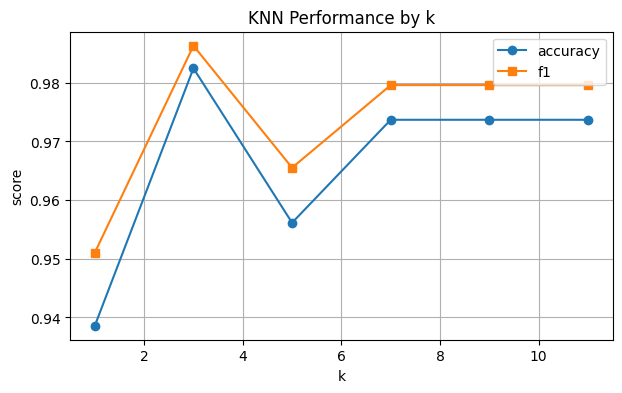

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(results_df["k"], results_df["accuracy"], marker='o', label='accuracy')
plt.plot(results_df["k"], results_df["f1"], marker='s', label='f1')
plt.xlabel("k")
plt.ylabel("score")
plt.title("KNN Performance by k")
plt.legend()
plt.grid(True)
plt.show()

**[Distance-Weighted Voting]**

In [ ]:
weighted_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
])

weighted_knn.fit(X_train, y_train)

evaluate_classifier(weighted_knn, X_test, y_test, "KNN (distance weighted)")

[KNN (distance weighted)]
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-score : 0.9655

Confusion Matrix
[[39  3]
 [ 2 70]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**[Scaling of attributes]**

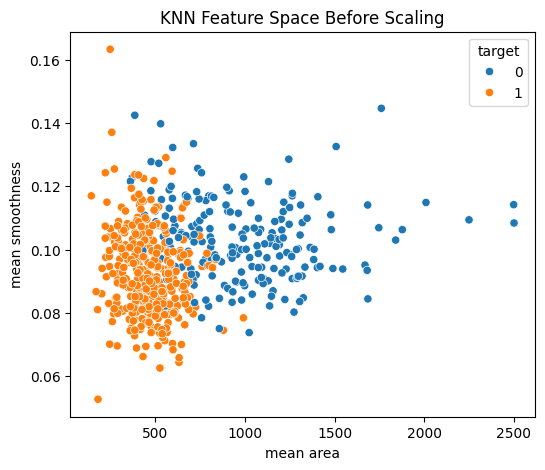

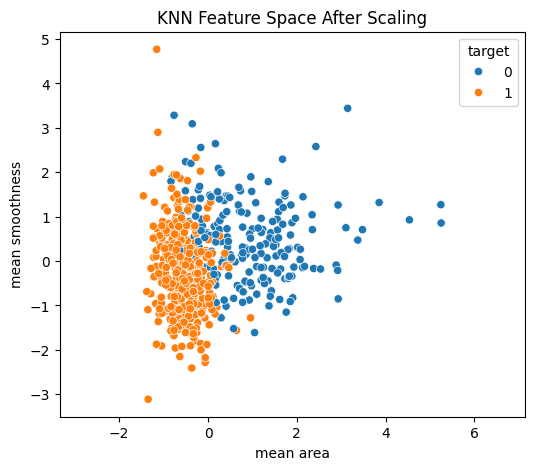

In [ ]:
a1='mean area'
a2='mean smoothness'

sample_df = pd.concat([X[[a1, a2]], y], axis=1)

plt.figure(figsize=(6, 5))
sns.scatterplot(data=sample_df, x=a1, y=a2, hue="target")
plt.title("KNN Feature Space Before Scaling")
plt.show()

scaled_sample = sample_df.copy()
scaled_sample[[a1, a2]] = StandardScaler().fit_transform(
    scaled_sample[[a1, a2]]
)

plt.figure(figsize=(6, 5))
plt.axis("equal")
sns.scatterplot(data=scaled_sample, x=a1, y=a2, hue="target")
plt.title("KNN Feature Space After Scaling")
plt.show()

In [ ]:
# scaling 없이
knn_no_scaling = KNeighborsClassifier(n_neighbors=5)
knn_no_scaling.fit(X_train, y_train)
pred_no_scaling = knn_no_scaling.predict(X_test)

print("[KNN without scaling]")
print("Accuracy:", round(accuracy_score(y_test, pred_no_scaling), 4))
print("F1-score:", round(f1_score(y_test, pred_no_scaling), 4))

print()

# scaling 포함
knn_with_scaling = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_with_scaling.fit(X_train, y_train)
pred_with_scaling = knn_with_scaling.predict(X_test)

print("[KNN with scaling]")
print("Accuracy:", round(accuracy_score(y_test, pred_with_scaling), 4))
print("F1-score:", round(f1_score(y_test, pred_with_scaling), 4))

print()

print("[Comparison]")
acc_diff = accuracy_score(y_test, pred_with_scaling) - accuracy_score(y_test, pred_no_scaling)
f1_diff = f1_score(y_test, pred_with_scaling) - f1_score(y_test, pred_no_scaling)

print("Accuracy improvement:", round(acc_diff, 4))
print("F1-score improvement:", round(f1_diff, 4))

[KNN without scaling]
Accuracy: 0.9123
F1-score: 0.9296

[KNN with scaling]
Accuracy: 0.9561
F1-score: 0.9655

[Comparison]
Accuracy improvement: 0.0439
F1-score improvement: 0.0359


**[Toy Example]**

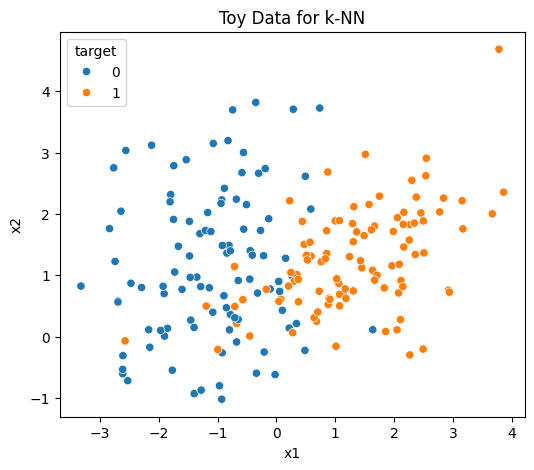

In [ ]:
# load dataset
X_toy, y_toy = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

toy_df = pd.DataFrame(X_toy, columns=["x1", "x2"])
toy_df["target"] = y_toy

plt.figure(figsize=(6, 5))
sns.scatterplot(data=toy_df, x="x1", y="x2", hue="target")
plt.title("Toy Data for k-NN")
plt.show()

In [ ]:
def plot_knn_boundary(X, y, k=5):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, weights in zip(axes, ['uniform', 'distance']):
        model = KNeighborsClassifier(n_neighbors=k, weights=weights)
        model.fit(X, y)

        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300),
            np.linspace(y_min, y_max, 300)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict(grid).reshape(xx.shape)

        ax.contourf(xx, yy, Z, alpha=0.25)
        sns.scatterplot(
            x=X[:, 0], y=X[:, 1], hue=y,
            edgecolor='k', ax=ax, legend=False
        )

        ax.set_title(f"k={k}, weights={weights}")
        ax.set_xlim(xx.min(), xx.max())
        ax.set_ylim(yy.min(), yy.max())

    plt.tight_layout()
    plt.show()


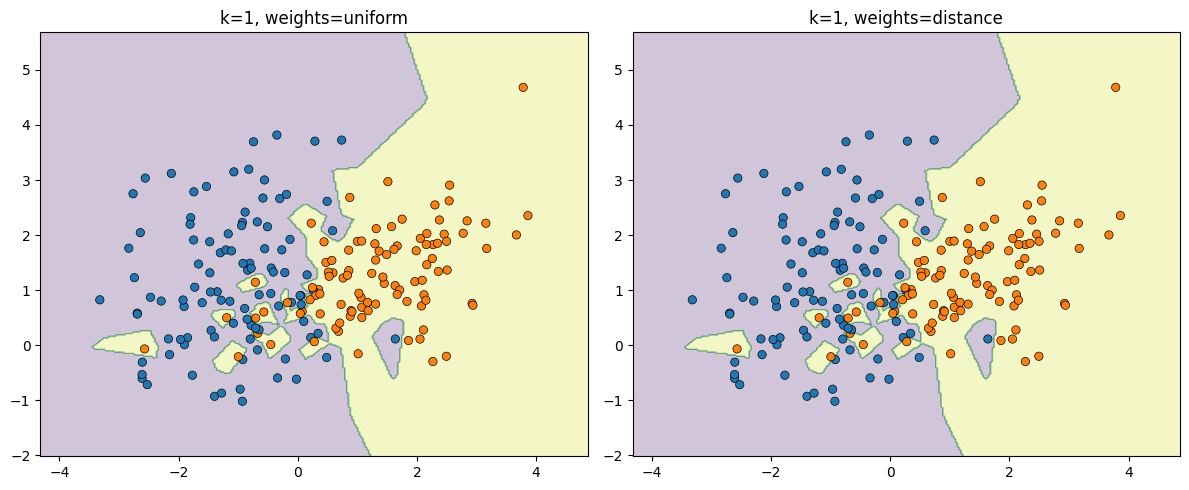

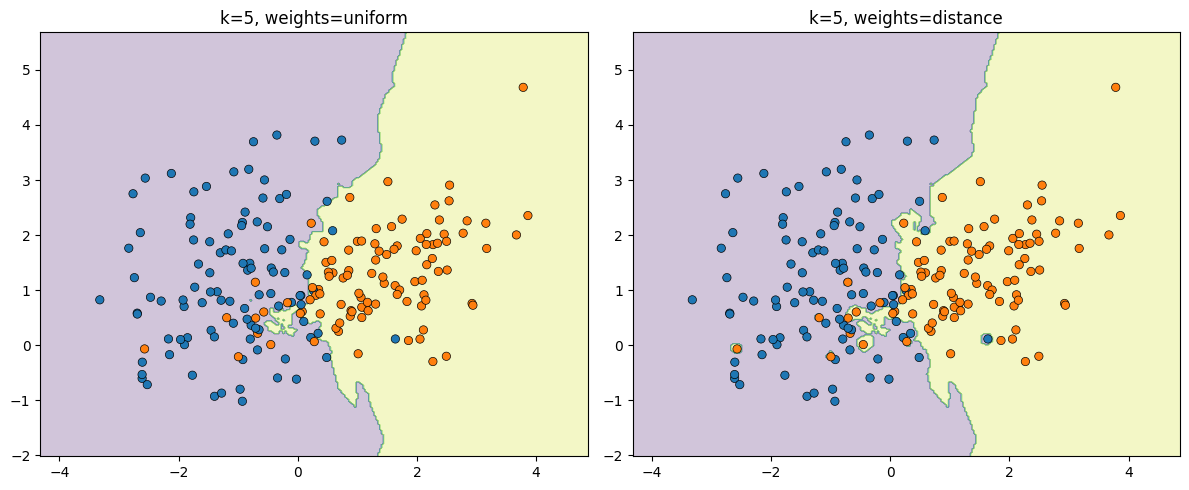

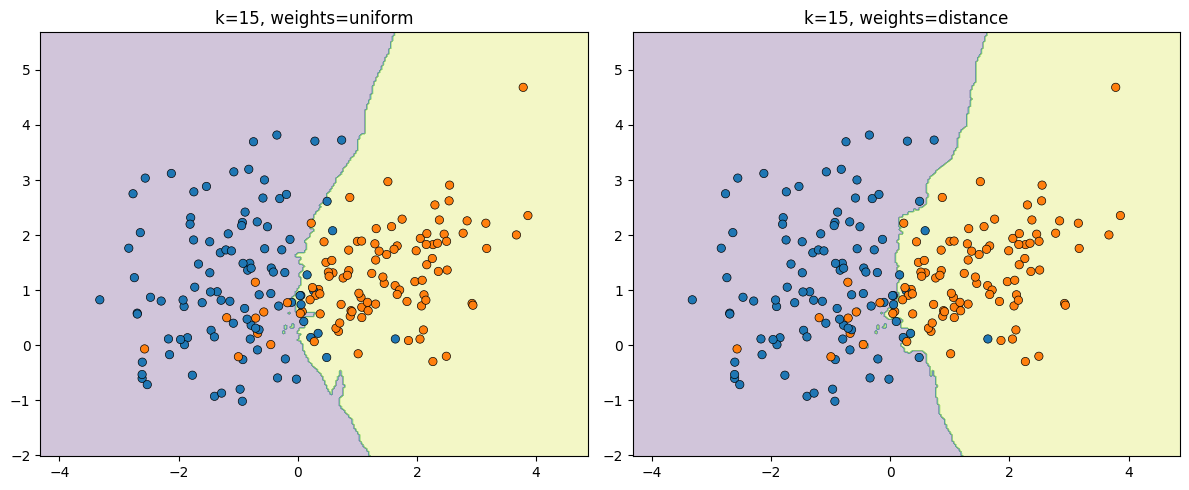

In [ ]:
for k in [1, 5, 15]:
  plot_knn_boundary(X_toy, y_toy, k=k)

---

## **Example 4**
세 가지 모델을 같은 데이터에 적용해서 결과를 비교하기

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Gaussian Naive Bayes": GaussianNB(),
    "KNN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])
}

comparison = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    comparison.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(comparison).sort_values(by="f1", ascending=False)
comparison_df

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
2,KNN (k=5),0.956140,0.958904,0.972222,0.965517
1,Gaussian Naive Bayes,0.938596,0.945205,0.958333,0.951724


-------

# **Quiz: Wine dataset**

**[Dataset]**
* [Wine](https://archive.ics.uci.edu/dataset/109/wine)
  * $X$: 화학 성분 기반 feature
  * $y$: 와인의 품종 (0, 1, 2)

**[Trainig]**
  * train 70%, test 30%
  * random state = 42

**[Evaluation]**
  * sklearn.metrics 라이브러리 활용
  * 소수점 4번째 자리까지 출력

**[Logistic Regression]**
  * StandardScaler를 포함한 Pipeline 만들기
  * model은 LogisticRegression 라이브러리 활용
    * 적절한 max iter 선택
    * random state = 42
  
**[Naive Bayes]**
  * A. Gaussian Naive Bayes
    * GaussianNB 라이브러리 활용
    * 첫 10개 샘플의 posterior probability 출력
  * B. Categorical Naive Bayes
    * CategoricalNB 라이브러리 활용
    * 각 continuous 변수를 4개 구간으로 discretization
  * GaussianNB와 CategoricalNB의 accuracy 비교

  **[KNN]**
  * StandardScaler를 포함한 KNN Pipeline 만들기
  * Rule of thumb $\boxed{k < \sqrt{n}}$ 주변의 값을 비교하여 최적의 k 찾기
  * 각 K에 대한 accuracy를 표로 정리

In [ ]:
from sklearn.datasets import load_wine

# load dataset
wine = load_wine()

X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="target")

print("X_wine shape:", X_wine.shape)
print("y_wine shape:", y_wine.shape)
print()
print("Class distribution")
print(y_wine.value_counts())

X_wine.head()

X_wine shape: (178, 13)
y_wine shape: (178,)

Class distribution
target
1    71
0    59
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
## train / test split

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine,
    test_size=0.3,
    random_state=42,
    stratify=y_wine
)

print("Train shape:", Xw_train.shape)
print("Test shape:", Xw_test.shape)

Train shape: (124, 13)
Test shape: (54, 13)


In [ ]:
# Logistic Regression

wine_logit = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

wine_logit.fit(Xw_train, yw_train)

yw_pred_logit = wine_logit.predict(Xw_test)

print("Accuracy:", round(accuracy_score(yw_test, yw_pred_logit), 4))
print()
print(confusion_matrix(yw_test, yw_pred_logit))

Accuracy: 0.9815

[[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


In [ ]:
# A. Gaussian Naive Bayes

wine_gnb = GaussianNB()

wine_gnb.fit(Xw_train, yw_train)

yw_pred_gnb = wine_gnb.predict(Xw_test)

print("Accuracy:", round(accuracy_score(yw_test, yw_pred_gnb), 4))
print()

wine_gnb_proba = wine_gnb.predict_proba(Xw_test)

wine_post_df = pd.DataFrame(
    wine_gnb_proba[:10],
    columns=["P(class=0)", "P(class=1)", "P(class=2)"]
)

display(wine_post_df)

Accuracy: 1.0



,P(class=0),P(class=1),P(class=2)
0,1.000000e+00,5.304355e-09,3.829858e-30
1,9.235394e-14,1.000000e+00,5.696707e-13
2,1.000000e+00,1.636433e-23,2.048887e-49
3,1.000000e+00,8.879427e-11,1.959591e-28
4,9.921924e-01,7.807594e-03,4.043592e-19
5,1.000000e+00,7.796345e-14,2.122113e-35
6,3.434982e-24,1.650712e-17,1.000000e+00
7,2.555557e-14,1.000000e+00,1.762029e-16
8,8.935465e-08,9.999999e-01,7.562175e-49
9,9.488035e-16,1.653220e-02,9.834678e-01


In [ ]:
# B. Categorical Naive Bayes

Xw_train_disc = Xw_train.copy()
Xw_test_disc = Xw_test.copy()

for col in Xw_train.columns:
    # train 기준으로 bin 경계 생성
    train_binned, bin_edges = pd.qcut(
        Xw_train[col],
        q=4,
        retbins=True,
        labels=False,
        duplicates='drop'
    )

    Xw_train_disc[col] = train_binned

    Xw_test_disc[col] = pd.cut(
        Xw_test[col],
        bins=bin_edges,
        labels=False,
        include_lowest=True
    )

Xw_train_disc.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
12,3,1,2,0,1,2,2,1,2,2,3,2,3
30,3,0,3,3,2,3,3,1,3,2,3,1,3
36,2,1,3,0,3,2,2,1,1,1,2,1,2
31,3,1,1,1,2,3,3,0,2,3,2,2,3
120,0,2,2,1,1,3,3,1,2,1,1,3,1


In [ ]:
# NaN 제거

mask = Xw_test_disc.notnull().all(axis=1)
Xw_test_disc_clean = Xw_test_disc[mask]
yw_test_disc_clean = yw_test[mask]

In [ ]:
from sklearn.naive_bayes import CategoricalNB

wine_cnb = CategoricalNB()

wine_cnb.fit(Xw_train_disc, yw_train)

yw_pred_cnb = wine_cnb.predict(Xw_test_disc_clean)

In [ ]:
print("Categorical NB Accuracy:", round(accuracy_score(yw_test_disc_clean, yw_pred_cnb), 4))
print("Gaussian NB Accuracy   :", round(accuracy_score(yw_test_disc_clean, wine_gnb.predict(Xw_test.loc[mask])), 4))

Categorical NB Accuracy: 0.9787
Gaussian NB Accuracy   : 1.0


In [ ]:
# KNN

# Rule of thumb
n_train = len(Xw_train)
k_rule = int(np.sqrt(n_train))

print("n_train =", n_train)
print("starting k =", k_rule)

# rule of thumb 주변 값들 비교
k_candidates = [k_rule-2, k_rule, k_rule+2, k_rule+4]

wine_knn_results = []

for k in k_candidates:
    wine_knn = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])

    wine_knn.fit(Xw_train, yw_train)
    yw_pred_knn = wine_knn.predict(Xw_test)

    wine_knn_results.append({
        "k": k,
        "accuracy": round(accuracy_score(yw_test, yw_pred_knn), 4)
    })

wine_knn_result_df = pd.DataFrame(wine_knn_results)
display(wine_knn_result_df)

n_train = 124
starting k = 11


,k,accuracy
0,9,0.9630
1,11,0.9630
2,13,0.9815
3,15,0.9815
